# TopoStats - Minicircle Walk-Through

Welcome, this [Jupyter Notebook](https://jupyter.org/) will take you through processing `minicricle.spm`

## Installing TopoStats

There are several different ways of installing TopoStats depending on what you want to do. The simplest is to install
from GitHub under a virtual environment.

```bash
pip install git+https://github.com/AFM-SPM/TopoStats/tree/dev
```

For more information on the different ways of installing TopoStats and setting up Virtual Environments please refer to
[installation](https://afm-spm.github.io/TopoStats/installation.html).



### Running in Colab

If you are running this Notebook in [Google Colab](https://colab.research.google.com/) then you will have to execute the
following cell in order to install TopoStats.

In [ ]:
pip install git+https://github.com/AFM-SPM/TopoStats/tree/dev

## Getting Started


### Loading Libraries and Modules

TopoStats is written as a series of modules with various classes and functions. In order to use these interactively we
need to `import` them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from topostats.filters import Filters
from topostats.grains import Grains
from topostats.grainstats import GrainStats
from topostats.io import read_yaml, write_yaml
from topostats.logs.logs import setup_logger, LOGGER_NAME
from topostats.plottingfuncs import plot_and_save
from topostats.tracing.dnatracing import dnaTrace, traceStats
from topostats.utils import find_images, get_out_path, update_config, convert_path, create_empty_dataframe

## Finding Files

TopoStats needs to find files to process and the `find_images()` function helps here. It takes as a argument the
directory path that should be searched and the file extension to look for (currently only `.spm` is supported) and
returns a list of all files that are found that have that file extension in the specified directory.

In [2]:
# Set the base directory to be current working directory of the Notebook
BASE_DIR = Path().cwd()
FILE_EXT = ".spm"
# Search for *.spm files in this directory
spm_files = find_images(base_dir=BASE_DIR.parent / "tests", file_ext=FILE_EXT)

`spm_files` is a list of images that match and we can look at that list.

In [3]:
spm_files

[PosixPath('/home/neil/work/projects/topostats/TopoStats/tests/resources/minicircle.spm')]

## Loading a Configuration

You can specify all options explicitly by hand when instantiating classes or calling methods/functions. However when run
at the command line in batch mode TopoStats loads these options from a [YAML](https://yaml.org/) configuration file and it is worth
understanding the structure of this file and how it is used.

A trimmed version is shown below. The words that come before the colon `:` are the option, e.g. `base_dir:` is the base
directory that is searched for files, what comes after is the value, in this case `./tests/`

**TODO** Insert example YAML file here once [#255](https://github.com/AFM-SPM/TopoStats/issues/255) is complete
```yaml
base_dir: ./tests/
output_dir: ./output
warnings: ignore
cores: 4
quiet: false
file_ext: .spm
filter:
  run: true # Options : true, false
  channel: Height
  amplify_level: 1.0
  threshold_method: std_dev # Options : otsu, std_dev, absolute
  otsu_threshold_multiplier: 1.0
  threshold_std_dev: 1.0
  threshold_absolute_lower: -1.0
  threshold_absolute_upper: 1.0
grains:
  run: true # Options : true, false
  gaussian_size: 2.0
  gaussian_mode: nearest
  absolute_smallest_grain_size: 100
  threshold_method: std_dev # Options : otsu, std_dev, absolute
  otsu_threshold_multiplier: 1.0
  threshold_std_dev: 1.0
  threshold_absolute_lower: -1.0
  threshold_absolute_upper: 1.0
  direction: upper # Options: upper, lower, both (defines whether to look for grains above or below thresholds or both)
  background: 0.0
grainstats:
  run: true # Options : true, false
  zrange: [0, 3]
  cropped_size: 40 # Length (in nm) of square cropped images (can take -1 for grain-sized box)
  save_cropped_grains: true # Options : true, false
dnatracing:
  run: true # Options : true, false
plotting:
  run: true # Options : true, false
  zrange: [0, 3]  # low and high height range for core images (can take [null, null])
  image_set: all  # Options : all, core
  colorbar: true  # Options : true, false
  cmap: nanoscope # Options : nanoscope, afmhot
```

To load the configuration file into Python we use the `read_yaml()` function. This saves the options as a dictionary and
we can access values by the keys.

In [4]:
from topostats.io import read_yaml
config = read_yaml(BASE_DIR.parent / "config" / "example.yaml")
print(f"Top level keys of config.ymal : \n\n {config.keys()}\n")
print(f"Configuration options for Filter : \n\n {config['filter'].keys()}")

Top level keys of config.ymal : 

 dict_keys(['base_dir', 'output_dir', 'warnings', 'cores', 'quiet', 'file_ext', 'filter', 'grains', 'grainstats', 'dnatracing', 'plotting'])

Configuration options for Filter : 

 dict_keys(['run', 'channel', 'amplify_level', 'threshold_method', 'otsu_threshold_multiplier', 'threshold_std_dev', 'threshold_absolute_lower', 'threshold_absolute_upper'])


You can look at all of the options using the `json` package to "pretty" print the dictionary which makes it easier to
read. Here we print the `filter` section. You can see the options map to those of the `Filter()` class with an
additional `"run": true` which is used when running TopoStats at the command line.

In [5]:
print(json.dumps(config["filter"], indent=4))

{
    "run": true,
    "channel": "Height",
    "amplify_level": 1.0,
    "threshold_method": "std_dev",
    "otsu_threshold_multiplier": 1.0,
    "threshold_std_dev": 1.0,
    "threshold_absolute_lower": -1.0,
    "threshold_absolute_upper": 1.0
}


We will use the configuration options we have loaded in processing the `minicircle.spm` image. For convenience we save
each set of options to their own dictionary and remove the `run` entry as this is not required when running TopoStats
interactively.


In [6]:
filter_config = config["filter"]
filter_config.pop("run")
grain_config = config["grains"]
grain_config.pop("run")
grainstats_config = config["grainstats"]
grainstats_config.pop("run")
dnatracing_config = config["dnatracing"]
dnatracing_config.pop("run")
plotting_config = config["plotting"]
plotting_config.pop("run")
plotting_dictionary = plotting_config["plot_dict"]

## Filter Image

Now that we have found some images the first step in processing is to filter them to remove some of the noise. This is
achieved using the `Filters()` class.  There are number of options that we need to specify which are described in the
table below and also in the [documentation](https://topostats.readthedocs.io/en/dev/topostats.filters.html). 

If you look carefully you will see there is mostly a one-to-one mapping between the options and the values in their
configuration. 

| Option                      | Type               | Description                                   | Default |
|:----------------------------|:-------------------|:----------------------------------------------|:--------|
| `img_path`                  | `Union[str, Path]` | The path to the image that is to be filtered. |         |
| `threshold_method`          | `str`              |                                               |         |
| `otsu_threshold_multiplier` | `float`            |                                               | 1.7     |
| `threshold_std_dev`         | `float`            |                                               | None    |
| `threshold_absolute_lower`  | `float`            |                                               | None    |
| `threshold_absolute_upper`  | `float`            |                                               | None    |
| `channel`                   | `str`              |                                               |         |
| `amplify_level`             | `float`            |                                               | `None`  |
| `output_dir`                | `Union[str, Path]` |                                               | `None`  |
| `quiet`                     | `bool`             |                                               | `False` |

One of the key fields you may wish to change is the `channel`.

Once we setup a `Filters` object we can call the different methods that are available for it. There are lots of
different methods that carry out the different steps but for convenience the `filter_image()` method runs all these.


In [7]:
from topostats.filters import Filters
filtered_image = Filters(spm_files[0],
                         threshold_method=config["filter"]["threshold_method"],
                         otsu_threshold_multiplier=config["filter"]["otsu_threshold_multiplier"],
                         threshold_std_dev=config["filter"]["threshold_std_dev"],
                         threshold_absolute_lower=config["filter"]["threshold_absolute_lower"],
                         threshold_absolute_upper=config["filter"]["threshold_absolute_upper"],
                         channel=config["filter"]["channel"],
                         amplify_level=config["filter"]["amplify_level"],
                         output_dir=config["output_dir"],
                         quiet=config["quiet"])

# NB - Because of the one-to-one mapping of configuration options to Filters() options we can use keyword arguments to
#      unpack the options, the below is the same as explicitly stating the values you want to map.
filtered_image = Filters(spm_files[0], **filter_config)
filtered_image.filter_image()


[Sat, 20 Aug 2022 11:29:16] [INFO    ] [topostats] Extracting filename from : /home/neil/work/projects/topostats/TopoStats/tests/resources/minicircle.spm


[Sat, 20 Aug 2022 11:29:16] [INFO    ] [topostats] Filename : minicircle


[Sat, 20 Aug 2022 11:29:16] [INFO    ] [topostats] Loading image from : /home/neil/work/projects/topostats/TopoStats/tests/resources/minicircle.spm


[Sat, 20 Aug 2022 11:29:16] [INFO    ] [topostats] [minicircle] : Loaded image from : /home/neil/work/projects/topostats/TopoStats/tests/resources/minicircle.spm


[Sat, 20 Aug 2022 11:29:16] [INFO    ] [topostats] Extracting filename from : /home/neil/work/projects/topostats/TopoStats/tests/resources/minicircle.spm


...

[Sat, 20 Aug 2022 11:29:17] [INFO    ] [topostats] [minicircle] : Y-gradient: -5.783605658230689e-06


[Sat, 20 Aug 2022 11:29:18] [INFO    ] [topostats] [minicircle] : X/Y tilt removed


[Sat, 20 Aug 2022 11:29:18] [INFO    ] [topostats] [minicircle] : Masking enabled


[Sat, 20 Aug 2022 11:29:18] [INFO    ] [topostats] [minicircle] : Row and column medians calculated.


[Sat, 20 Aug 2022 11:29:18] [INFO    ] [topostats] [minicircle] : Zero averaging background


The `filtered_image` now has a a number of NumPy arrays saved in the `.images` dictionary that can be accessed and plotted. To view
the names of the images (technically the dictionary keys) you can...

In [8]:
print(f"Available NumPy arrays to plot in filter_image.images dictionary :\n\n{filtered_image.images.keys()}")

Available NumPy arrays to plot in filter_image.images dictionary :

dict_keys(['scan_raw', 'extracted_channel', 'pixels', 'initial_align', 'initial_tilt_removal', 'masked_align', 'masked_tilt_removal', 'zero_averaged_background', 'mask'])


To plot the raw extracted pixels you can use the built-in NumPy method `imshow()`.


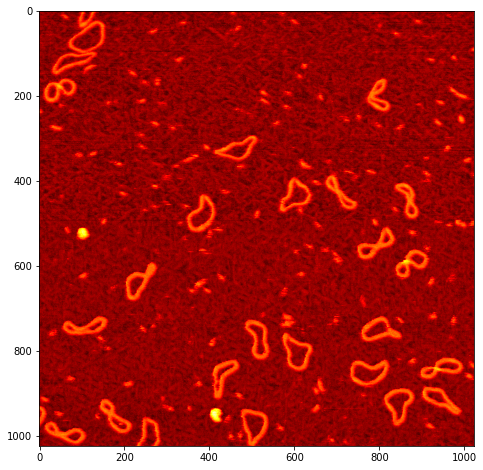

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(filtered_image.images["pixels"], cmap='hot')
plt.show()

TopoStats includes a custom plotting function though called `plot_and_save()` which formats plots in a more familiar
manner.

It has a number of options 

| Option                       | Type            | Description                                                 |
|:-----------------------------|-----------------|-------------------------------------------------------------|
| `data`                       | `np.ndarray`    | 2-D Numpy array of data to be plotted.                      |
| `output_dir`                 | `str` or `Path` | Location to save resulting image.                           |
| `filename`                   | `str`           | Filename to save as.                                                            |
| `pixel_to_nm_scaling_factor` | `float`         |                                                             |
| `data2`                      | `np.array`      |                                                             |
| `title`                      | `str`           | Title for plot.                                                            |
| `type`                       | `str`           |                                                             |
| `image_set`                  | `str`           |                                                             |
| `core_set`                   | `bool`          |                                                             |
| `interpolation`              | `str`           |                                                             |
| `cmap`                       | `str`           | The colormap to use when plotting.                          |
| `region_properties`          | `dict`          |                                                             |
| `zrange`                     | `list`          | Range of values to constrain (clip) the height (z-axis) to. |
| `colorbar`                   | `bool`          | Whether to include a colorbar at the side.                  |
| `save`                       | `bool`          | Whether to actually save the file to disk.                  |


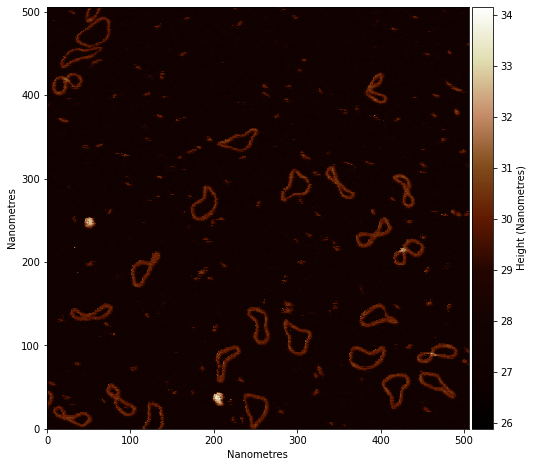

In [10]:
fig, ax = plot_and_save(data=filtered_image.images["pixels"],
                        filename=filtered_image.filename,
                        output_dir="img/",
                        pixel_to_nm_scaling_factor=filtered_image.pixel_to_nm_scaling,
                        save=False)
fig

Here we plot the image after processing and zero-averaging the background but with the `viridis` palette and
constraining the `zrange` to be between 0 and 3

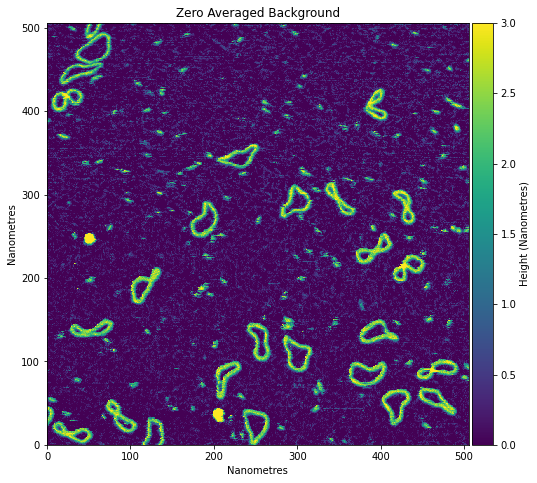

In [11]:
fig, ax = plot_and_save(data=filtered_image.images["zero_averaged_background"],
                        filename=filtered_image.filename,
                        output_dir="img/",
                        pixel_to_nm_scaling_factor=filtered_image.pixel_to_nm_scaling,
                        title="Zero Averaged Background",
                        cmap="viridis",
                        zrange=[0,3],
                        save=False)
fig

## Finding Grains

The next step in processing the image is to find grains. This is done using the `Grains` class.

| Option                         | Type               | Description | Default   |
|:-------------------------------|:-------------------|:------------|:----------|
| `image`                        | `np.ndarray`       |             |           |
| `filename`                     | `str`              |             |           |
| `pixel_to_nm_scaling`          | `float`            |             |           |
| `gaussian_size`                | `float`            |             | `2`       |
| `gaussian_mode`                | `str`              |             | `nearest` |
| `threshold_method`             | `str`              |             | `None`    |
| `otsu_threshold_multiplier`    | `float`            |             | `None`    |
| `threshold_std_dev`            | `float`            |             | `None`    |
| `threshold_absolute_lower`     | `float`            |             | `None`    |
| `threshold_absolute_upper`     | `float`            |             | `None`    |
| `absolute_smallest_grain_size` | `float`            |             | `None`    |
| `direction`                    | `str`              |             |           |
| `background`                   | `float`            |             | `0.0`     |
| `base_output_dir`              | `Union[str, Path]` |             | `None`    |

The most important thing required for grain finding is the resulting image from the Filtering stage, however several
other key variables are required. Again there is a one-to-one mapping between the options to the `Grains()` class and
their values in the configuration file.

The `pixel_to_nm_scaling` is one of several key variables, as is the `filename` and whilst you can specify these
yourself explicitly they are available as properties of the `filtered_image` that we have processed. As with `Filters`
the `Grains` class has a number of methods that carry out the grain finding, but there is a convenience method
`find_grains()` which calls all these in the correct order.

In [12]:
from topostats.grains import Grains
grains = Grains(image=filtered_image.images["zero_averaged_background"],
                filename=filtered_image.filename,
                pixel_to_nm_scaling=filtered_image.pixel_to_nm_scaling,
                gaussian_size=config["grains"]["gaussian_size"],
                gaussian_mode=config["grains"]["gaussian_mode"],
                threshold_method=config["grains"]["threshold_method"],
                otsu_threshold_multiplier=config["grains"]["otsu_threshold_multiplier"],
                threshold_std_dev=config["grains"]["threshold_std_dev"],
                threshold_absolute_lower=config["grains"]["threshold_absolute_lower"],
                threshold_absolute_upper=config["grains"]["threshold_absolute_upper"],
                absolute_smallest_grain_size=config["grains"]["absolute_smallest_grain_size"],
                background=config["grains"]["background"],
                base_output_dir= Path(config["output_dir"]) / filtered_image.filename / "grains",
                )
# NB - Again we can use the one-to-one mapping of configuration options in the grain_config we extracted.
grains = Grains(image=filtered_image.images["zero_averaged_background"],
                filename=filtered_image.filename,
                pixel_to_nm_scaling=filtered_image.pixel_to_nm_scaling,
                **grain_config,
                base_output_dir= Path(config["output_dir"]) / filtered_image.filename / "grains")
grains.find_grains()


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Thresholding method (grains) : std_dev


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Processing upper threshold (0.8064132139225288)


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Applying Gaussian filter (mode : nearest; Gaussian blur (nm) : 2.0).


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Masking (upper) Threshold: 0.8064132139225288


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Tidying borders


...

[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Removed small objects (< 1118.8548853759764)


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Labelling Regions


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Region properties calculated (upper)


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Coloured regions


[Sat, 20 Aug 2022 11:29:32] [INFO    ] [topostats] [minicircle] : Extracted bounding boxes (upper)


The `grains` object now also contains a series of images in the `grains.images` dictionary that we can plot.

In [13]:
print(f"Available NumPy arrays to plot in grains.images dictionary :\n\n{grains.images.keys()}")

Available NumPy arrays to plot in grains.images dictionary :

dict_keys(['gaussian_filtered', 'z_threshed', 'mask_grains', 'tidied_border', 'tiny_objects_removed', 'objects_removed'])


And we can again use the `plot_and_save()` function to plot these.

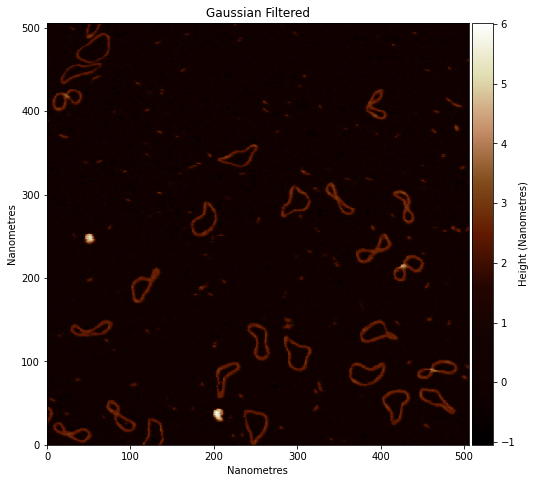

In [14]:
fig, ax = plot_and_save(data=grains.images["gaussian_filtered"],
                        filename="z_threshed.png",
                        pixel_to_nm_scaling_factor=grains.pixel_to_nm_scaling,
                        title="Gaussian Filtered",
                        output_dir="img/")
fig

### Thresholds

The thresholds can be used in different ways based on the `direction` you want to detect grains. Typically for molecular
imaging where the DNA or protein is raised above the background you will want to look for items above the `upper`
threshold. When imaging silicon though you may be interested in items below a `lower` threshold. For convenience it is
possible to look for grains that are `both` above the `upper` threshold and `lower` than the lower threshold.

This is controlled using the `config["grains"]["direction"]` configuration option which maps to the `Grains(direction=)`
option and can take three values `lower`, `upper` or `both`.

If you want to change the option you can update the `config["grains"]` dictionary as we do below. You will see that now
we are using `both` there is twice as much output as grains are detected above the reported upper Threshold (0.8064)
_and_ below the reported lower Threshold (-0.5333).

In [15]:
grain_config["direction"] = "both"
grains_both = Grains(image=filtered_image.images["zero_averaged_background"],
                filename=filtered_image.filename,
                pixel_to_nm_scaling=filtered_image.pixel_to_nm_scaling,
                **grain_config,
                base_output_dir= Path(config["output_dir"]) / filtered_image.filename / "grains")
grains_both.find_grains()


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Thresholding method (grains) : std_dev


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Processing upper threshold (0.8064132139225288)


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Applying Gaussian filter (mode : nearest; Gaussian blur (nm) : 2.0).


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Masking (upper) Threshold: 0.8064132139225288


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Tidying borders


...

[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Labelling Regions


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Region properties calculated (lower)


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Coloured regions


[Sat, 20 Aug 2022 11:29:40] [INFO    ] [topostats] [minicircle] : Extracted bounding boxes (lower)


/home/neil/.virtualenvs/topostats/lib/python3.10/site-packages/skimage/_shared/utils.py:157: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)


There above method is using `threshold_method="std_dev"` defined in the configuration file we loaded. This calculates the
mean and standard deviation of height across the whole image and then determines the threshold by scaling the standard
deviation by a given factor (defined by `threshold_std_dev`) and adding it to the mean to give the `upper` threshold
and/or subtracting if from the mean to give the `lower` threshold.

An alternative method is to use the `threshold_method="absolute"` and explicitly state the `threshold_absolute_lower`
and `threshold_absolute_upper` values you wish to use in conjunction with the desired `direction`. Here we look for
grains above the `upper` `absolute` value of 2.0

In [16]:
grain_config["threshold_method"] = "absolute"
grain_config["direction"] = "upper"
grain_config["threshold_absolute_upper"] = 2.0
grains_absolute = Grains(image=filtered_image.images["zero_averaged_background"],
                filename=filtered_image.filename,
                pixel_to_nm_scaling=filtered_image.pixel_to_nm_scaling,
                **grain_config,
                base_output_dir= Path(config["output_dir"]) / filtered_image.filename / "grains")
grains_absolute.find_grains()

[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Thresholding method (grains) : absolute


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Processing upper threshold (2.0)


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Applying Gaussian filter (mode : nearest; Gaussian blur (nm) : 2.0).


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Masking (upper) Threshold: 2.0


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Tidying borders


...

[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Removed small objects (< 605.647591796875)


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Labelling Regions


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Region properties calculated (upper)


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Coloured regions


[Sat, 20 Aug 2022 11:29:43] [INFO    ] [topostats] [minicircle] : Extracted bounding boxes (upper)


This is important to know because you need to know where the resulting imagse are stored within the `Grains.direction`
dictionary. This will have entries corresponding to the `direction` that grains have been searched for.

In [17]:
print(f"Grains available in original 'grains' (std_dev, upper) : {grains.directions.keys()}")
print(f"Grains available in both (std_dev, both)               : {grains_both.directions.keys()}")
print(f"Grains available in absolute (absolute, upper)         : {grains_absolute.directions.keys()}")

Grains available in original 'grains' (std_dev, upper) : dict_keys(['upper'])
Grains available in both (std_dev, both)               : dict_keys(['upper', 'lower'])
Grains available in absolute (absolute, upper)         : dict_keys(['upper'])


Each `direction` dictionary is a series of NumPy arrays representing the cleaned images and these can be plotted.

Images available for plotting : dict_keys(['mask_grains', 'tidied_border', 'removed_noise', 'labelled_regions_01', 'removed_small_objects', 'labelled_regions_02', 'coloured_regions'])


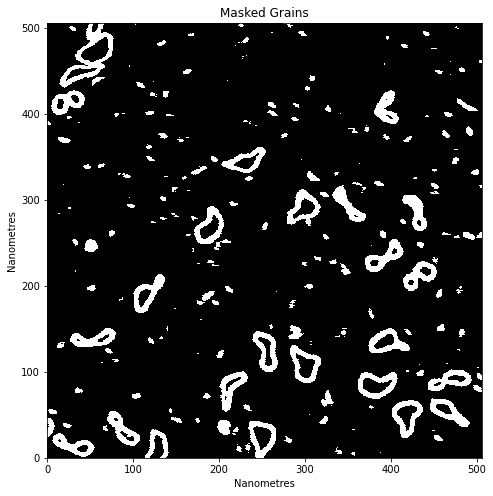

In [18]:
print(f"Images available for plotting : {grains.directions['upper'].keys()}")
fig, ax = plot_and_save(data=grains.directions["upper"]["mask_grains"],
                        filename="mask_grain.png",
                        pixel_to_nm_scaling_factor=grains.pixel_to_nm_scaling,
                        title="Masked Grains",
                        colorbar=False,
                        output_dir="img/")
fig

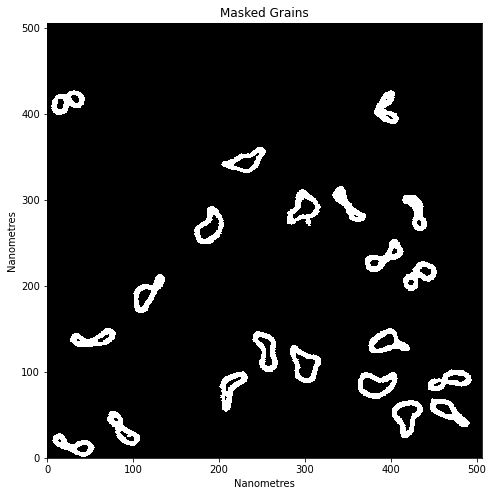

In [19]:
fig, ax = plot_and_save(data=grains.directions["upper"]["removed_small_objects"],
                        filename="mask_grain.png",
                        pixel_to_nm_scaling_factor=grains.pixel_to_nm_scaling,
                        title="Masked Grains",
                        colorbar=False,
                        output_dir="img/")
fig

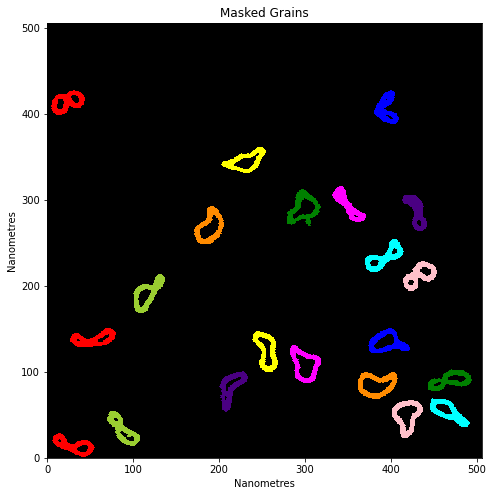

In [20]:
fig, ax = plot_and_save(data=grains.directions["upper"]["coloured_regions"],
                        filename="mask_grain.png",
                        pixel_to_nm_scaling_factor=grains.pixel_to_nm_scaling,
                        title="Masked Grains",
                        colorbar=False,
                        output_dir="img/")
fig

## Grain Statistics

Now that grains have been found we can calculate statistics on each of the grains. This is done using the `GrainStats()`
class. Again the configuration options from the YAML file map to those of the class and there is a convenience method
`calculate_stats()` which will run all steps of grain finding. This method returns a dictionary with `statistics`
containing the calculated statistics for each grain and `plot` which is a plot of the grains with bounding boxes.

| Option                       | Type               | Description | Default        |
|:-----------------------------|:-------------------|:------------|:---------------|
| `data`                       | `np.ndarray`       |             |                |
| `labelled_data`              | `np.ndarray`       |             |                |
| `pixel_to_nanometre_scaling` | `float`            |             |                |
| `direction`                  | `str`              |             |                |
| `base_output_dir`            | `Union[str, Path]` |             |                |
| `image_name`                 | `str`              |             | `None`         |
| `zrange`                     | `list`             |             | `[None, None]` |
|                              |                    |             |                |




[Sat, 20 Aug 2022 11:29:55] [INFO    ] [topostats] [minicircle] : Processing grain: 0


[Sat, 20 Aug 2022 11:29:55] [INFO    ] [topostats] [minicircle] : Image saved to : grains/upper/minicircle_processed_grain_0.png


[Sat, 20 Aug 2022 11:29:56] [INFO    ] [topostats] [minicircle] : Processing grain: 1


[Sat, 20 Aug 2022 11:29:56] [INFO    ] [topostats] [minicircle] : Image saved to : grains/upper/minicircle_processed_grain_1.png


[Sat, 20 Aug 2022 11:29:56] [INFO    ] [topostats] [minicircle] : Processing grain: 2


...

[Sat, 20 Aug 2022 11:30:02] [INFO    ] [topostats] [minicircle] : Image saved to : grains/upper/minicircle_processed_grain_18.png


[Sat, 20 Aug 2022 11:30:02] [INFO    ] [topostats] [minicircle] : Processing grain: 19


[Sat, 20 Aug 2022 11:30:02] [INFO    ] [topostats] [minicircle] : Image saved to : grains/upper/minicircle_processed_grain_19.png


[Sat, 20 Aug 2022 11:30:03] [INFO    ] [topostats] [minicircle] : Processing grain: 20


[Sat, 20 Aug 2022 11:30:03] [INFO    ] [topostats] [minicircle] : Image saved to : grains/upper/minicircle_processed_grain_20.png


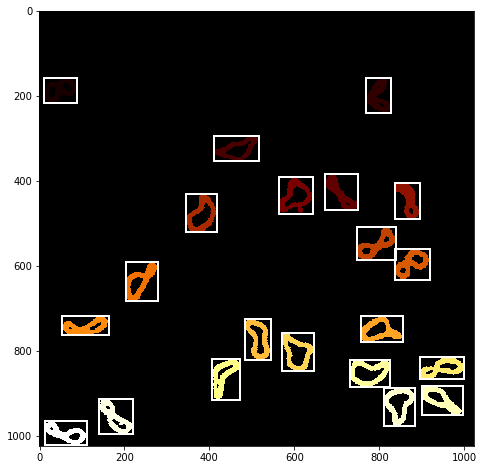

In [21]:
grainstats = GrainStats(data=grains.images["gaussian_filtered"],
                        labelled_data=grains.directions["upper"]["labelled_regions_02"],
                        pixel_to_nanometre_scaling=filtered_image.pixel_to_nm_scaling,
                        direction="upper",
                        base_output_dir="grains",
                        image_name=filtered_image.filename,
                        image_set=plotting_config["image_set"],
                        **grainstats_config)
grain_stats = grainstats.calculate_stats()

The `statistics` is a [Pandas
DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html). We can print this out as
shown below.

In [22]:
grain_stats["statistics"]

,centre_x,centre_y,radius_min,radius_max,radius_mean,radius_median,height_min,height_max,height_median,height_mean,volume,area,area_cartesian_bbox,smallest_bounding_width,smallest_bounding_length,smallest_bounding_area,aspect_ratio,threshold
Molecule Number,,,,,,,,,,,,,,,,,,
0,18.707007,96.557844,5.704484,20.868161,15.487836,16.147027,0.807228,3.872404,2.068618,1.979001,1209.314584,611.073392,1137.465287,23.833883,41.299524,984.327993,1.732807,upper
1,400.791989,92.687445,1.156515,21.954307,13.681085,14.462380,0.808306,3.184813,2.153402,2.015619,1252.350418,621.323025,1166.261877,27.021623,39.031234,1054.687294,1.444444,upper
2,217.783058,173.228087,8.327489,28.527665,17.743395,16.360454,0.806422,3.088319,2.002073,1.895022,1138.574169,600.823758,1577.955492,24.191610,54.065589,1307.933633,2.234890,upper
3,353.728516,207.406570,3.923541,25.897458,15.301596,15.862244,0.807987,3.104159,2.138802,2.016266,1214.373036,602.287992,1619.442104,17.774995,49.449371,878.962307,2.781963,upper
4,300.793755,212.102937,10.149579,25.325110,17.923324,18.380428,0.806753,3.002725,1.926512,1.865175,1306.808409,700.635666,1719.742090,32.927338,43.990574,1448.492500,1.335989,upper
5,432.420548,215.785933,2.875581,23.466926,15.068693,15.781069,0.807625,3.244689,2.192315,2.045040,1238.690130,605.704536,1238.253351,20.607085,45.698864,941.720385,2.217629,upper
6,194.525710,231.200777,9.008959,23.627316,17.816803,18.014840,0.807147,2.893983,2.055561,1.935035,1291.532044,667.446377,1559.408536,29.666377,45.282153,1343.357407,1.526380,upper
7,389.744542,274.397786,2.080837,25.551359,16.667871,18.344349,0.806572,3.044685,2.229112,2.058189,1440.533706,699.903550,1770.258141,22.716236,49.213645,1117.948783,2.166452,upper
8,430.344334,295.941830,2.896435,22.126524,15.426546,16.421498,0.806487,4.425863,2.229864,2.112985,1382.974509,654.512315,1420.794444,26.255766,42.786388,1123.389372,1.629600,upper


Further we can summarise the dataframe or a subset of varaibles.

In [23]:
grain_stats["statistics"][["smallest_bounding_width", "aspect_ratio"]].describe()

,smallest_bounding_width,aspect_ratio
count,21.000000,21.000000
mean,25.424271,1.954090
std,5.001914,0.482739
min,17.774995,1.188391
25%,21.630208,1.526380
50%,25.341383,2.017915
75%,27.759526,2.301894
max,35.564081,2.781963


## DNA Tracing

When working with molecules it is possible to calculate DNA Tracing Statistics using the `dnaTrace` and `traceStats`
classes.

**NB** These classes are likely to undergo refactoring and change in the coming months, this Notebook will be updated
in light of changes. Currently there are very few options that map to the configuration. For that reason the options are
not currently detailed and described in this Notebook, although the [API
Documentation](https://afm-spm.github.io/TopoStats/topostats.tracing.html) details them.

Currently this is a two stage process

1. `dnaTrace` traces molecules to produce a "trace_object".
2. `traceStats` takes the "trace_object" and produces a Pandas DataFrame

In [24]:
from topostats.tracing.dnatracing import dnaTrace, traceStats
dna_traces = dnaTrace(full_image_data=grains.images["gaussian_filtered"],
                      grains=grains.directions["upper"]["labelled_regions_02"],
                      filename=grains.filename,
                      pixel_size=grains.pixel_to_nm_scaling,
                      **dnatracing_config)
dna_traces.trace_dna()
tracing_stats = traceStats(trace_object=dna_traces,
                           image_path=spm_files[0])

[Sat, 20 Aug 2022 11:30:08] [INFO    ] [topostats] Performing DNA Tracing


[Sat, 20 Aug 2022 11:30:08] [INFO    ] [topostats] [minicircle] : Gaussian filter applied.


[Sat, 20 Aug 2022 11:30:12] [INFO    ] [topostats] There are 12 circular and 9 linear DNA molecules found in the image


The resulting Pandas DataFrame is stored in the `df` attribute of the `traceStats` object, to view it we...

In [25]:
tracing_stats.df

,Contour Lengths,Circular,End to End Distance,Image Name,Basename
Molecule Number,,,,,
0,96.379020,True,0.000000,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
1,155.481357,False,18.331436,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
2,274.229824,False,2.964018,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
3,119.323180,False,27.438294,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
4,89.291557,True,0.000000,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
5,145.631155,False,19.011092,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
6,104.810175,True,0.000000,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
7,33.357609,True,0.000000,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...
8,57.577148,True,0.000000,minicircle.spm,/home/neil/work/projects/topostats/TopoStats/t...


### Merge GrainStats and TracingStats

Its reasonable to want to have a single data set with which we work and so we now merge the GrainStats data frame with
the Tracing Stats. 

In [26]:
all_stats_df = grain_stats["statistics"].merge(tracing_stats.df, on=["Molecule Number"])
all_stats_df.columns

Index(['centre_x', 'centre_y', 'radius_min', 'radius_max', 'radius_mean',
       'radius_median', 'height_min', 'height_max', 'height_median',
       'height_mean', 'volume', 'area', 'area_cartesian_bbox',
       'smallest_bounding_width', 'smallest_bounding_length',
       'smallest_bounding_area', 'aspect_ratio', 'threshold',
       'Contour Lengths', 'Circular', 'End to End Distance', 'Image Name',
       'Basename'],
      dtype='object')

## Plotting

A single Pandas DataFrame of grain and tracing statistics is now available. TopoStats includes a number of functions for
plotting these in the `Plotting` module from the old v1, currently these have not yet been incorporated into TopoStats v2.

We can however plot statistics directly using the methods available to plot Pandas DataFrames (the `Plotting` module is
a wrapper to these commands that simplifies and makes consistent a number of the steps described below).

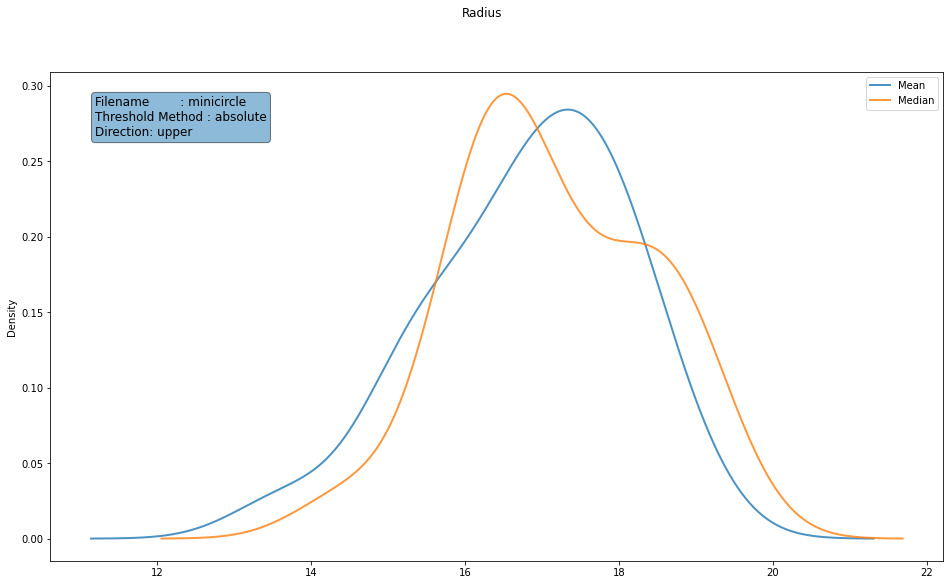

In [28]:
PLOT_OPTS = {"alpha": 0.8,
             "linewidth": 2.0}
fig, ax = plt.subplots(figsize=(16, 9))
all_stats_df[["radius_mean", "radius_median"]].plot.kde(ax=ax, **PLOT_OPTS)
plt.suptitle("Radius")
textstr = "\n".join([f"Filename        : {spm_files[0].stem}",
                     f"Threshold Method : {config['grains']['threshold_method']}",
                     f"Direction: {config['grains']['direction']}"])
props = dict(boxstyle="round", alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment="top", bbox=props)
plt.legend(["Mean", "Median"])